# VeryCloudy — Basic Analysis

All plotting logic lives in `src/verycloudy/analysis.py`.  
This notebook only loads data, calls functions, and displays results.

**To switch between testset and full dataset:** change the import in cell 0 between  
`FILEPATH_FULL_TESTSET` (default, small) and `FILEPATH_FULL` (production).

In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt

from verycloudy.analysis import (
    summary_table,
    completeness_bar,
    rows_per_year,
    country_counts,
    top_countries_bar,
    world_choropleth,
    cloud_type_bar,
    subtype_bar,
    cooccurrence_heatmap,
    weather_histograms,
    boxplots_by_cloudtype,
    scatter_cape_vs_clouds,
    scatter_dew_spread_by_cloudtype,
    scatter_low_vs_high_cover,
    scatter_humidity_dew,
)
from verycloudy.styling import standard_style
from verycloudy.config import FILEPATH_FULL_TESTXL  # swap to FILEPATH_FULL for production

standard_style()

# Load the combined dataset (cloud rows + no-cloud rows merged into one file)
df = pd.read_csv(FILEPATH_FULL_TESTXL)
print(f"Loaded {len(df)} rows, {df.columns.tolist()}")

Loaded 16300 rows, ['lightbox_id', 'image_url', 'date_iso', 'date_raw', 'author_name', 'author_profile', 'title', 'tags', 'status', 'date_taken', 'time_taken', 'date_taken_utc_xmp', 'time_taken_utc_xmp', 'datetime_source', 'fallback_dt_used', 'datetime_capture', 'city', 'region', 'country', 'latitude', 'longitude', 'location_source', 'dt_unix', 'date_taken_utc_y', 'time_taken_utc_y', 'temp', 'feels_like', 'pressure', 'humidity', 'dew_point', 'clouds', 'clouds_low', 'clouds_mid', 'clouds_high', 'wind_speed', 'wind_deg', 'wind_gust', 'visibility', 'weather_code', 'rain_1h', 'snow_1h', 'uvi', 'cloud_type1', 'cloud_type2', 'cloud_type3', 'subtype1', 'subtype2', 'cloud_type_fix', 'is_cloudy', 'source_field', 'fallback_used', 'error', 'date_taken_utc', 'time_taken_utc']


---
## 1. Dataset overview

In [6]:
display(summary_table(df))

,column,filled,missing,fill_pct
0,total rows,16300,0,100.0
1,date range,1980-01-01,,
2,date range end,2026-03-28,,
3,unique countries,150,,
4,latitude,16300,0,100.0
5,longitude,16300,0,100.0
6,date_taken,16300,0,100.0
7,time_taken,16300,0,100.0
8,temp,16298,2,100.0
9,clouds,16298,2,100.0


In [16]:
nocloudclassification = df[
    df["cloud_type1"].isna() & 
    df["subtype1"].isna() &
    df["is_cloudy"]
].shape[0]
isnotcloudy = df[df['is_cloudy'] == False].shape[0]

print(f"There are {nocloudclassification} rows without a cloud classification. \nThe rows where retrieved from CAS-website, but it was not possible to retrieve the cloud type from title or tags.\n")
print(f"There are {isnotcloudy} row in the database with value 'False' in column 'is_cloudy'. \nThese rows are added by selecting non-cloudy date/time/location from OpenMeteo.")

There are 565 rows without a cloud classification. 
The rows where retrieved from CAS-website, but it was not possible to retrieve the cloud type from title or tags.

There are 100 row in the database with value 'False' in column 'is_cloudy'. 
These rows are added by selecting non-cloudy date/time/location from OpenMeteo.


In [24]:
nolocation = df[df["latitude"].isna()].shape[0]
print(nolocation)
# dit is hier zo omdat ik de testsetxl bekomen heb door een kopie van de clouds_weather, dus clouds_weather_testxl te inner mergen met de volledige cloud_gallery_with_date_location. Ik had dus datum en locatie al en toen heb ik daar het weer aan toegevoegd. Maar met ongelijke datasets op dat moment, want ik wilde al kunnen werken met meer weergegevens dan ik al had (de 1000). Maar in de weather-data zitten geen gegevens zonder locatie want die gaan we niet oproepen. 

0


In [21]:
nocloudclassification_df = df[
    df["cloud_type1"].isna() & 
    df["subtype1"].isna() &
    df["is_cloudy"]
]

cols = ["lightbox_id", "title", "tags", "date_taken", "time_taken"]
nocloudclassification_df[cols].head(10)


,lightbox_id,title,tags,date_taken,time_taken
225,671031,Northern Lights (Aurora Borealis) spotted near...,"A classic example, At night, Northern/Southern...",2025-11-11,21:40:03
375,668375,Northern Lights (Aurora Borealis) over Brighto...,"A classic example, At night, Northern/Southern...",2025-11-16,11:00:00
1301,653022,The joy Charlotte felt was palpable when she r...,Northern/Southern Lights,2024-10-10,22:02:15
1836,645794,"Anti-crepuscular rays near Baltimore, Maryland...","Sunset / Sunrise, Crepuscular rays & shadows",2019-09-20,19:32:32
2216,640146,A faint red aurora borealis spotted over Crank...,"At night, Northern/Southern Lights",2025-03-26,20:15:06
2276,639253,"Rainbow over Kew, Australia","App Photo of the Day, Rainbow",2025-03-19,11:00:00
2287,639136,"Fallstreak Hole over Gulangyu, China",App Photo of the Day,2025-03-18,11:00:00
2295,639039,"Corona over Lochbuie, United States","Corona, App Photo of the Day",2025-03-17,11:00:00
2329,638627,"Sun Pillar over Oberndorf, Germany","App Photo of the Day, Sun pillar",2025-03-13,11:00:00
2351,638384,"Kelvin-Helmholtz over Langeraar, The Netherlands",App Photo of the Day,2025-03-11,11:00:00


In [26]:
noweather = df[
    df["temp"].isna()
].shape[0]
print(noweather)

2


In [3]:
noweather_df = df[
    df["temp"].isna()
]
cols = ["lightbox_id", "title", "tags", "date_taken", "time_taken", "cloud_type1", "subtype1", "temp", 'humidity', 'dew_point', 'clouds']
noweather_df[cols].head(2)

,lightbox_id,title,tags,date_taken,time_taken,cloud_type1,subtype1,temp,humidity,dew_point,clouds
14932,141719,"A Mackerel sky with teeth over Mount Boron, Ni...","Clouds that look like things, Our favourites, ...",2003-08-28,07:57:54,altocumulus,contrail,NaN,NaN,NaN,NaN
14933,141715,"A Hang Glider and Halo over Traben-Trarbach, G...","22° Halo, Cirrus, Halos, Upper tangent arc",2016-05-11,15:38:37,cirrus,NaN,NaN,NaN,NaN,NaN


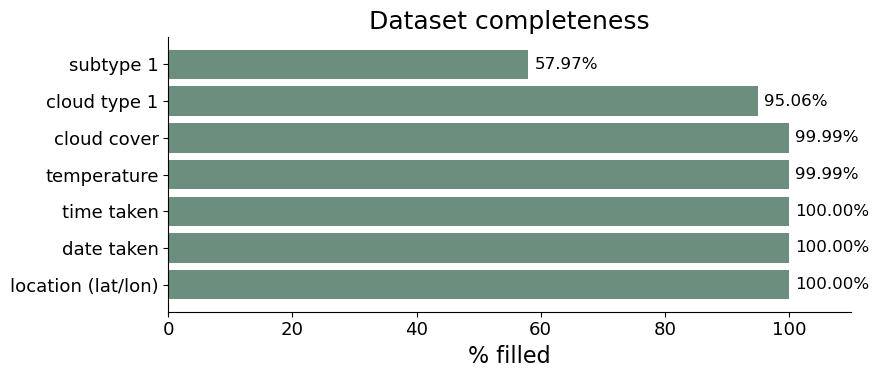

In [5]:
fig = completeness_bar(df)
plt.show()

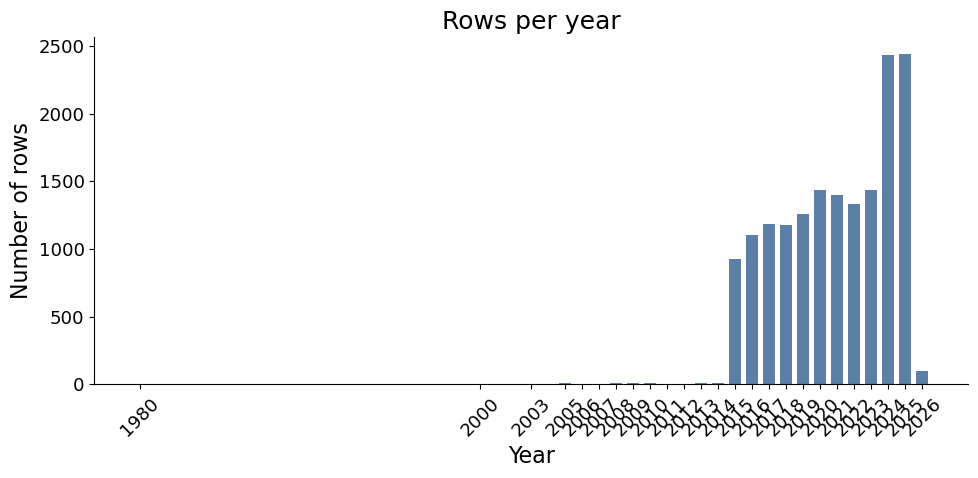

In [6]:
fig = rows_per_year(df)
plt.show()

---
## 2. Geographic spread

In [1]:
display(country_counts(df).head(15).rename('count').to_frame())

NameError: name 'country_counts' is not defined

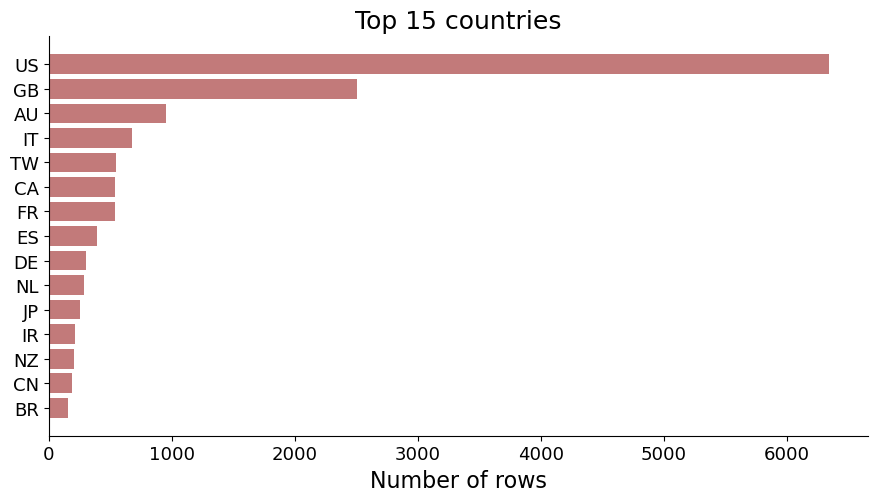

In [9]:
fig = top_countries_bar(df, n=15)
plt.show()

In [10]:
fig = world_choropleth(df)
fig.show()

---
## 3. Cloud types

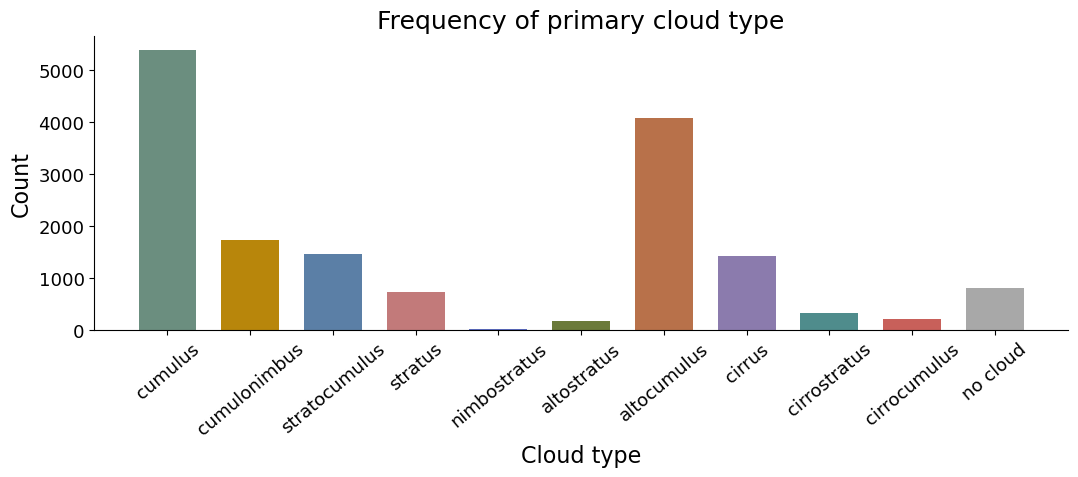

In [11]:
fig = cloud_type_bar(df)
plt.show()

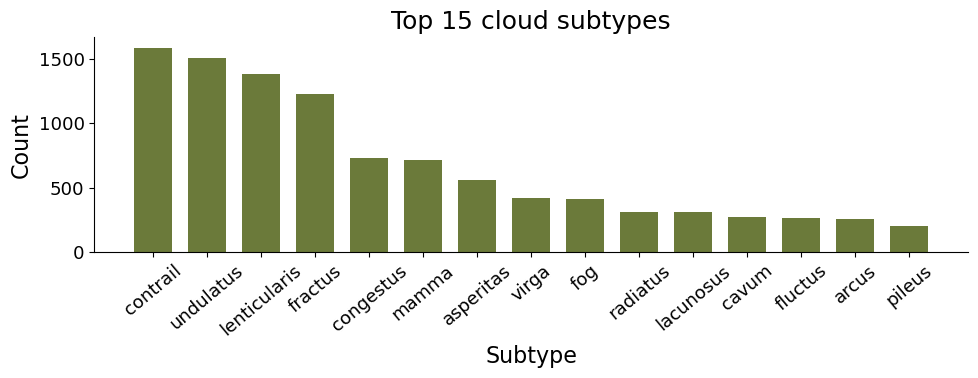

In [12]:
fig = subtype_bar(df, n=15)
plt.show()

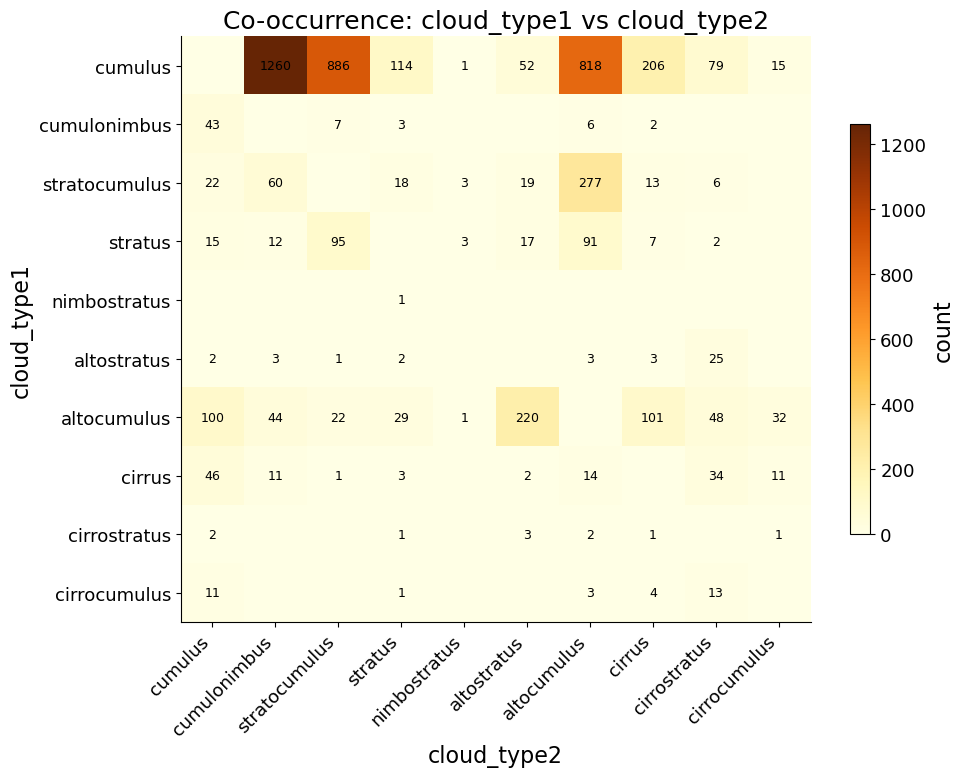

In [13]:
# Co-occurrence on cloudy rows only (rows that have a cloud_type1)
df_cloudy = df[df['cloud_type1'].notna()]
fig = cooccurrence_heatmap(df_cloudy)
plt.show()

---
## 4. Weather distributions

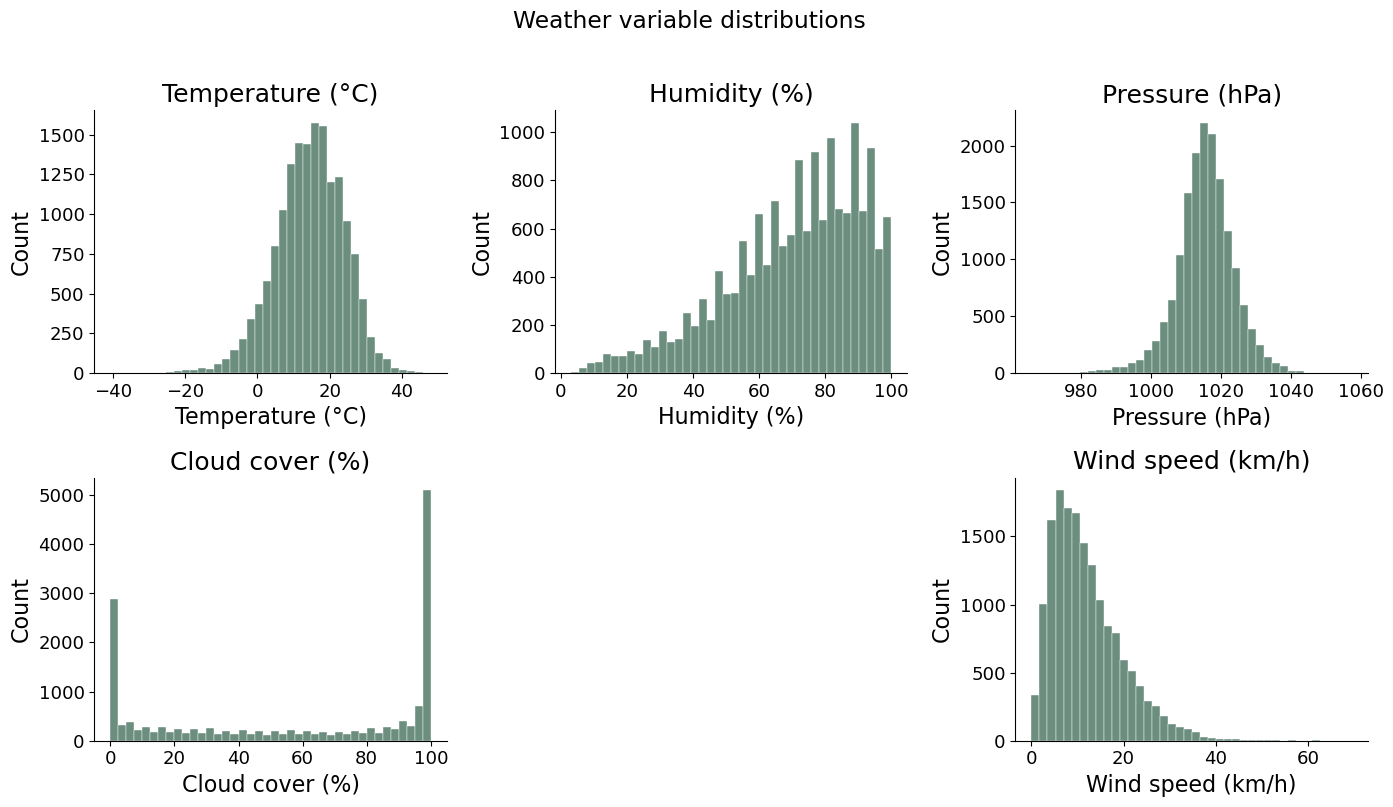

In [14]:
fig = weather_histograms(df)
plt.show()

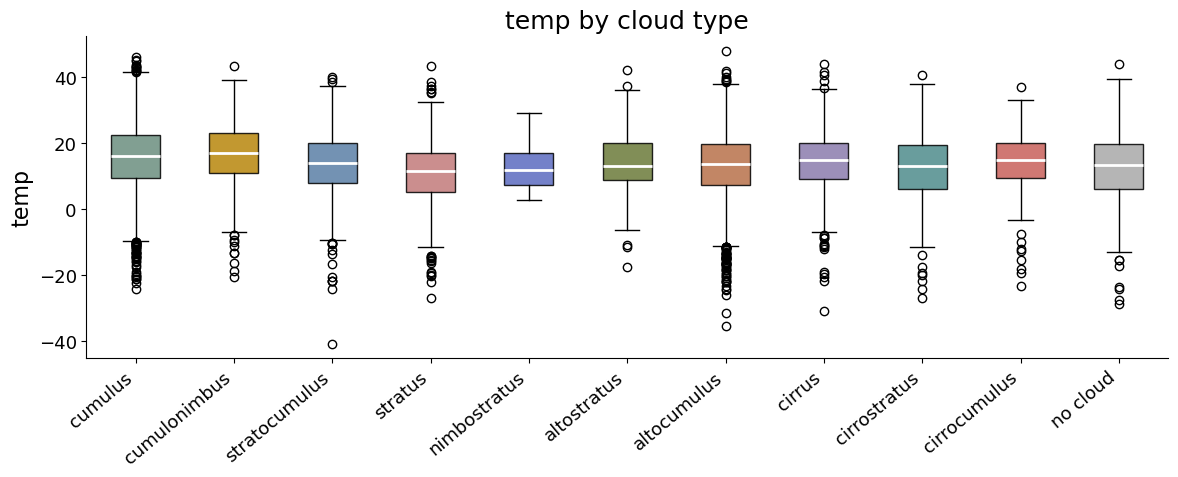

In [15]:
fig = boxplots_by_cloudtype(df, 'temp')
plt.show()

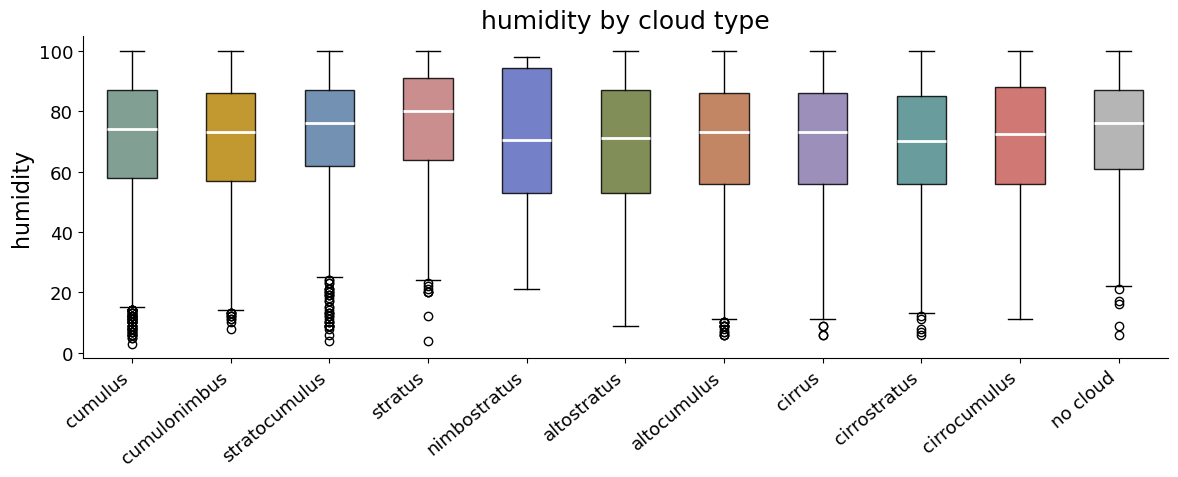

In [16]:
fig = boxplots_by_cloudtype(df, 'humidity')
plt.show()

---
## 5. Cloud type vs weather

These charts are designed to show the meteorological signal behind each cloud type —
useful for the oral exam and as motivation for the ML model features.

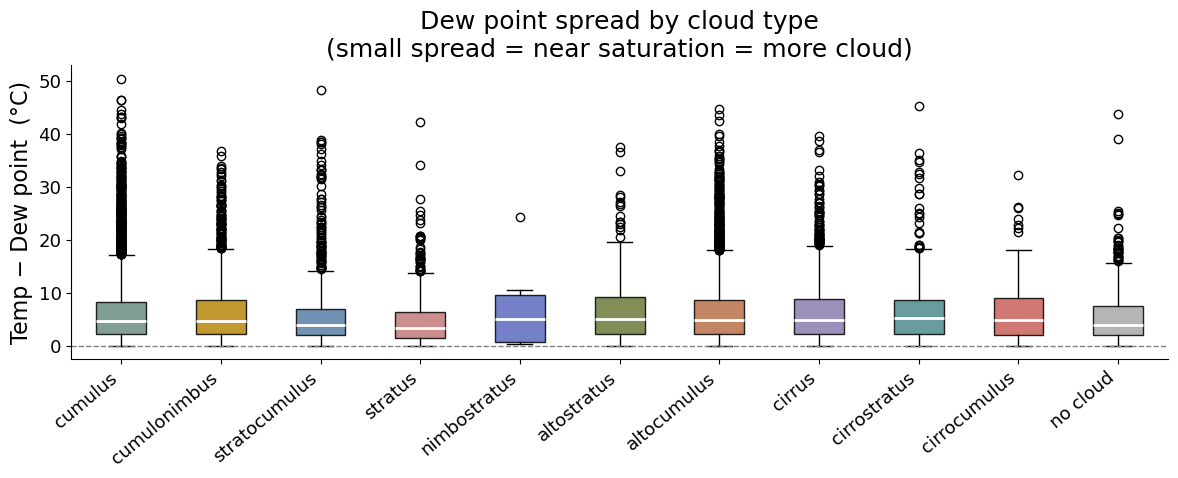

In [17]:
# Dew point spread (temp - dew_point) by cloud type — low spread = humid/stratiform, high = dry/convective
fig = scatter_dew_spread_by_cloudtype(df)
plt.show()

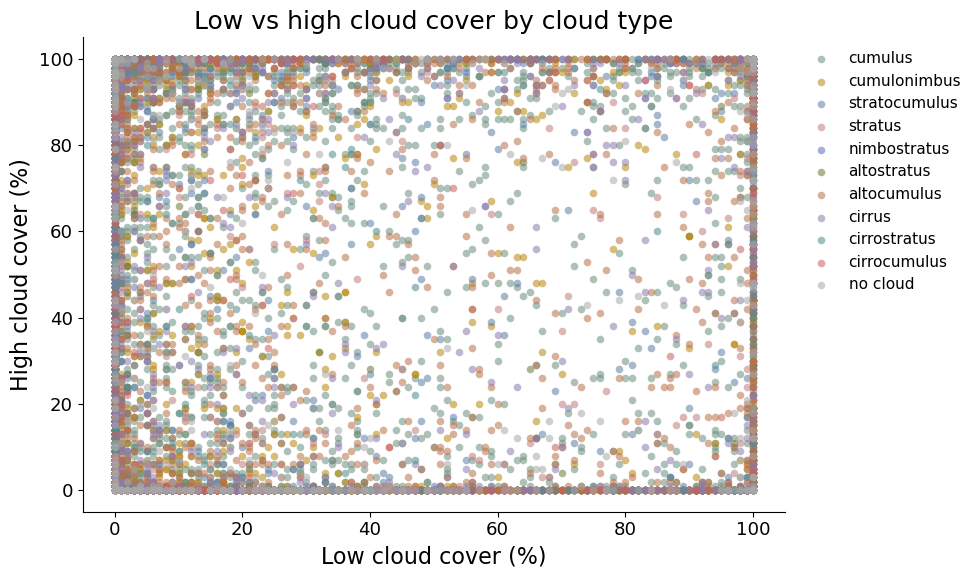

In [18]:
# Low vs high cloud cover — cloud family separation
fig = scatter_low_vs_high_cover(df)
plt.show()

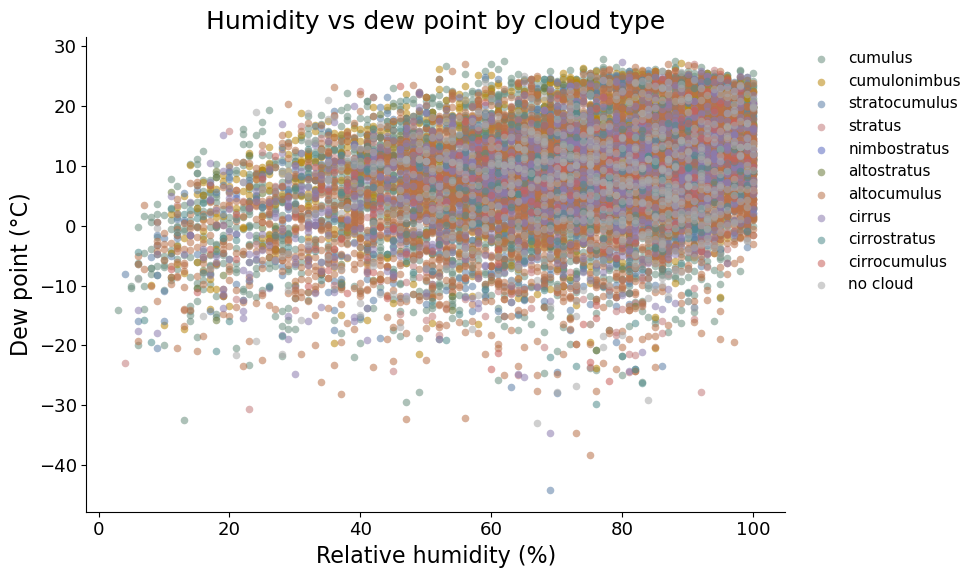

In [19]:
# Humidity vs dew point — stratiform clouds cluster at high humidity
fig = scatter_humidity_dew(df)
plt.show()